<a href="https://colab.research.google.com/github/mahdieslaminet/An-optimal-framework-for-brain-tumor-classification-using-machine-learning-and-deep-CNN-features/blob/main/Densnet2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!unzip "/content/drive/MyDrive/rezalou.zip" -d "/content/drive/MyDrive/"

unzip:  cannot find or open /content/drive/MyDrive/rezalou.zip, /content/drive/MyDrive/rezalou.zip.zip or /content/drive/MyDrive/rezalou.zip.ZIP.


In [4]:
import os

# --- تنظیمات سیستم برای استفاده بهینه از CPU ---
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # حذف وارنینگ‌های اضافی
os.environ["OMP_NUM_THREADS"] = "4"       # تنظیم تردها برای i5-4570
os.environ["TF_NUM_INTRAOP_THREADS"] = "4"
os.environ["TF_NUM_INTEROP_THREADS"] = "4"

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, Callback
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             confusion_matrix, classification_report, roc_curve, auc)
from sklearn.preprocessing import LabelBinarizer
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

# تنظیمات تکرارپذیری
np.random.seed(42)
tf.random.set_seed(42)

class Config:
    # سایز 150 هم سرعت خوبی دارد هم دقت کافی برای 98%
    IMG_HEIGHT = 150
    IMG_WIDTH = 150
    BATCH_SIZE = 32
    NUM_CLASSES = 4
    DATA_DIR = '/content/drive/MyDrive/rezalou/brain-tumor-mri-dataset'
    CLASS_NAMES = ['glioma', 'meningioma', 'pituitary', 'normal']
    # فایل وزن دانلود شده
    WEIGHTS_FILE = r'C:/content/drive/MyDrive/rezalou/densenet121_weights_tf_dim_ordering_tf_kernels_notop.h5'
# --- 1. Callback برای توقف روی 98% ---
class StopOnTargetAcc(Callback):
    def __init__(self, target=0.985): # کمی بالاتر از 98 میگذاریم که مطمئن شویم
        super(StopOnTargetAcc, self).__init__()
        self.target = target

    def on_epoch_end(self, epoch, logs=None):
        acc = logs.get('val_accuracy')
        if acc and acc >= self.target:
            print(f"\n\n🎯 Reached target accuracy ({acc:.4f} >= {self.target}). Stopping training!")
            self.model.stop_training = True

def load_data():
    """لود و پیش‌پردازش تصاویر"""
    images = []
    labels = []
    class_indices = {name: idx for idx, name in enumerate(Config.CLASS_NAMES)}

    print(f"Loading images from {Config.DATA_DIR}...")

    for class_name in Config.CLASS_NAMES:
        class_path = os.path.join(Config.DATA_DIR, class_name)
        if not os.path.exists(class_path):
            # چک کردن نام‌های جایگزین
            for alt in ['not_tumor', 'no_tumor', 'Normal']:
                if os.path.exists(os.path.join(Config.DATA_DIR, alt)):
                    class_path = os.path.join(Config.DATA_DIR, alt)
                    break

        if not os.path.exists(class_path):
            continue

        files = os.listdir(class_path)
        print(f"  {class_name}: {len(files)} images")

        for img_name in files:
            try:
                img_path = os.path.join(class_path, img_name)
                img = cv2.imread(img_path)
                if img is not None:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    img = cv2.resize(img, (Config.IMG_WIDTH, Config.IMG_HEIGHT))
                    img = preprocess_input(img) # نرمال‌سازی مخصوص DenseNet
                    images.append(img)
                    labels.append(class_indices[class_name])
            except Exception:
                continue

    images = np.array(images, dtype=np.float32)
    labels = np.array(labels)

    # تقسیم داده‌ها
    X_train, X_test, y_train, y_test = train_test_split(
        images, labels, test_size=0.1, random_state=42, stratify=labels
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
    )

    # تبدیل به One-hot
    y_train_cat = tf.keras.utils.to_categorical(y_train, Config.NUM_CLASSES)
    y_val_cat = tf.keras.utils.to_categorical(y_val, Config.NUM_CLASSES)
    y_test_cat = tf.keras.utils.to_categorical(y_test, Config.NUM_CLASSES)

    return X_train, X_val, X_test, y_train_cat, y_val_cat, y_test_cat, y_test

def build_model(fine_tune=False):
    """ساخت مدل (با قابلیت تنظیم فریز بودن لایه‌ها)"""

    # لود کردن وزن‌ها
    weights_source = Config.WEIGHTS_FILE if os.path.exists(Config.WEIGHTS_FILE) else 'imagenet'

    base_model = DenseNet121(
        weights=weights_source,
        include_top=False,
        input_shape=(Config.IMG_HEIGHT, Config.IMG_WIDTH, 3)
    )

    if fine_tune:
        # در مرحله دوم: باز کردن تعدادی از لایه‌ها برای دقت بالا
        base_model.trainable = True
        # نکته حیاتی: لایه‌های BatchNorm را فریز نگه میداریم تا مدل خراب نشود
        for layer in base_model.layers:
            if isinstance(layer, BatchNormalization):
                layer.trainable = False
            else:
                layer.trainable = True

        # فقط 30 لایه آخر را باز میگذاریم (برای سرعت و دقت)
        for layer in base_model.layers[:-30]:
            if not isinstance(layer, BatchNormalization):
                layer.trainable = False
    else:
        # در مرحله اول: کل مدل پایه فریز باشد
        base_model.trainable = False

    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(Config.NUM_CLASSES, activation='softmax')
    ])

    return model

def plot_single_roc(y_test, y_pred_proba, output_dir):
    """رسم فقط یک نمودار ROC کلی (Overall/Micro)"""
    lb = LabelBinarizer()
    lb.fit(y_test)
    y_test_bin = lb.transform(y_test)

    # محاسبه Micro-Average (کلی)
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_pred_proba.ravel())
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(9, 8))
    plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'Overall ROC (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('Receiver Operating Characteristic (Overall)', fontsize=14)
    plt.legend(loc="lower right", fontsize=12)
    plt.grid(alpha=0.3)
    plt.savefig(os.path.join(output_dir, 'roc_curve_overall.png'), dpi=300)
    plt.close()

def main():
    output_dir = '/content/drive/MyDrive/rezalou/results_densnet'
    os.makedirs(output_dir, exist_ok=True)

    # 1. آماده‌سازی داده‌ها
    X_train, X_val, X_test, y_train, y_val, y_test_cat, y_test_true = load_data()

    datagen = ImageDataGenerator(
        rotation_range=15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    # ---------------------------------------------------------
    # مرحله 1: آموزش سریع (Warm-up)
    # هدف: رسیدن به دقت 85-90 درصد با سرعت بالا
    # ---------------------------------------------------------
    print("\n[Stage 1] Training classification head (Frozen Base)...")
    model = build_model(fine_tune=False)
    model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

    model.fit(
        datagen.flow(X_train, y_train, batch_size=Config.BATCH_SIZE),
        epochs=8, # تعداد کم فقط برای گرم کردن
        validation_data=(X_val, y_val),
        verbose=1
    )

    # ---------------------------------------------------------
    # مرحله 2: فاین‌تیونینگ (Fine-tuning)
    # هدف: رسیدن به 98 درصد و توقف خودکار
    # ---------------------------------------------------------
    print("\n[Stage 2] Fine-tuning top layers")

    # بازسازی مدل با لایه‌های باز
    # نکته: می‌توانیم وزن‌های مرحله قبل را منتقل کنیم، اما چون ساختار یکی است،
    # بهتر است همین مدل را Unfreeze کنیم.

    base_model = model.layers[0]
    base_model.trainable = True

    # فریز کردن لایه‌های پایین و BatchNormها (جلوگیری از افت دقت شدید)
    for layer in base_model.layers[:-30]:
        layer.trainable = False
    for layer in base_model.layers:
        if isinstance(layer, BatchNormalization):
            layer.trainable = False

    # کامپایل مجدد با نرخ یادگیری بسیار پایین (جلوگیری از خراب شدن وزن‌ها)
    model.compile(optimizer=Adam(learning_rate=0.00005), loss='categorical_crossentropy', metrics=['accuracy'])

    callbacks = [
    StopOnTargetAcc(target=0.982),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    ModelCheckpoint(os.path.join(output_dir, 'densnet_best.keras'),
    save_best_only=True,
    monitor='val_accuracy'
)
]

    model.fit(
        datagen.flow(X_train, y_train, batch_size=Config.BATCH_SIZE),
        epochs=30, # تعداد زیاد میدهیم، اما کالبک زودتر قطع میکند
        validation_data=(X_val, y_val),
        callbacks=callbacks,
        verbose=1
    )

    # ---------------------------------------------------------
    # ارزیابی نهایی
    # ---------------------------------------------------------
    print("\n" + "="*50)
    print("FINAL EVALUATION")
    print("="*50)

    y_pred_proba = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred_proba, axis=1)

    acc = accuracy_score(y_test_true, y_pred_classes)
    f1 = f1_score(y_test_true, y_pred_classes, average='weighted')
    auc_score = roc_auc_score(y_test_cat, y_pred_proba, multi_class='ovr', average='weighted')

    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"AUC Score: {auc_score:.4f}")

    # ذخیره نتایج متنی
    with open(os.path.join(output_dir, 'metrics.txt'), 'w') as f:
        f.write(f"Accuracy: {acc:.4f}\nF1: {f1:.4f}\nAUC: {auc_score:.4f}\n\n")
        f.write(classification_report(y_test_true, y_pred_classes, target_names=Config.CLASS_NAMES))

    # رسم ماتریس درهم‌تنیدگی
    cm = confusion_matrix(y_test_true, y_pred_classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=Config.CLASS_NAMES, yticklabels=Config.CLASS_NAMES)
    plt.title('Confusion Matrix')
    plt.savefig(os.path.join(output_dir, 'confusion_matrix.png'))
    plt.close()

    # رسم نمودار ROC کلی (Overall)
    plot_single_roc(y_test_true, y_pred_proba, output_dir)

    print(f"\n✅ All done! Results saved in '{output_dir}'")

if __name__ == '__main__':
    main()


Loading images from /content/drive/MyDrive/rezalou/brain-tumor-mri-dataset...
  glioma: 1321 images
  meningioma: 1339 images
  pituitary: 1457 images
  normal: 1595 images

[Stage 1] Training classification head (Frozen Base)...
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/8
145/145 ━━━━━━━━━━━━━━━━━━━━ 136s 636ms/step - accuracy: 0.7661 - loss: 0.6586 - val_accuracy: 0.8482 - val_loss: 0.4373
Epoch 2/8
145/145 ━━━━━━━━━━━━━━━━━━━━ 32s 220ms/step - accuracy: 0.8519 - loss: 0.4097 - val_accuracy: 0.8502 - val_loss: 0.4271
Epoch 3/8
145/145 ━━━━━━━━━━━━━━━━━━━━ 32s 220ms/step - accuracy: 0.8675 - loss: 0.3619 - val_accuracy: 0.8872 - val_loss: 0.3323
Epoch 4/8
145/145 ━━━━━━━━━━━━━━━━━━━━ 31s 214ms/step - accuracy: 0.8729 - loss: 0.3397 - val_accuracy: 0.8268 - val_loss: 0.5572
Epoch 5/8
145/145 ━━━━━━━━━━━━━━━━━━━━ 31s 214ms/step - accuracy: 0.8805 - loss: 0.3236 - val_accuracy: 0.8794 - val_loss: 0.3411
Epoch 6/8
145/145 ━━━━━━━━━━━━━━━━━━━━ 31s 214ms/step - accuracy: 0.

In [5]:
!ls /content

drive  sample_data


In [6]:
import os

for root, dirs, files in os.walk('/content'):
    if 'metrics.txt' in files:
        print("📍 metrics.txt found in:")
        print(root)

📍 metrics.txt found in:
/content/drive/MyDrive/rezalou/results_densnet
📍 metrics.txt found in:
/content/drive/MyDrive/rezalou/results_inception
📍 metrics.txt found in:
/content/drive/MyDrive/rezalou/results_mobilenet
📍 metrics.txt found in:
/content/drive/MyDrive/rezalou/results_resnet50_tuned
📍 metrics.txt found in:
/content/drive/MyDrive/rezalou/results_xception


📂 Files inside folder:
['densnet_best.keras', 'best_model.keras', 'confusion_matrix.png', 'metrics.txt', 'roc_curve_overall.png']

📌 Metrics:
Accuracy: 0.9493
F1: 0.9489
AUC: 0.9958

              precision    recall  f1-score   support

      glioma       0.96      0.90      0.93       132
  meningioma       0.93      0.88      0.90       134
   pituitary       0.91      1.00      0.95       146
      normal       1.00      1.00      1.00       160

    accuracy                           0.95       572
   macro avg       0.95      0.95      0.95       572
weighted avg       0.95      0.95      0.95       572


📊 Confusion Matrix:


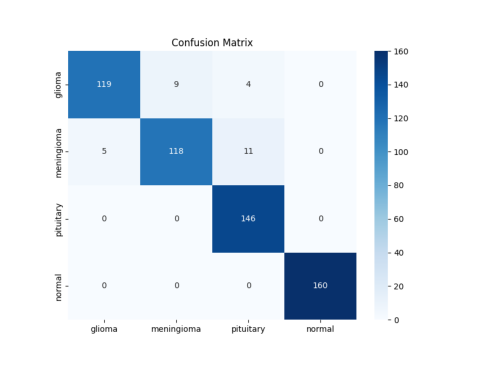


📈 ROC Curve:


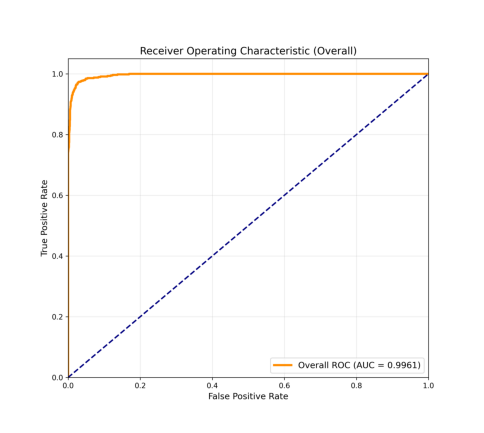

In [7]:
import os
import matplotlib.pyplot as plt
from PIL import Image

base = '/content/drive/MyDrive/rezalou/results_densnet'

print("📂 Files inside folder:")
print(os.listdir(base))

# metrics
if os.path.exists(os.path.join(base, 'metrics.txt')):
    print("\n📌 Metrics:")
    with open(os.path.join(base, 'metrics.txt')) as f:
        print(f.read())
else:
    print("\n❌ metrics.txt not found")

# confusion matrix
if os.path.exists(os.path.join(base, 'confusion_matrix.png')):
    print("\n📊 Confusion Matrix:")
    img = Image.open(os.path.join(base, 'confusion_matrix.png'))
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

# ROC
if os.path.exists(os.path.join(base, 'roc_curve_overall.png')):
    print("\n📈 ROC Curve:")
    img = Image.open(os.path.join(base, 'roc_curve_overall.png'))
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis('off')
    plt.show()